In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from xgboost import XGBRegressor

In [2]:
# Cargar el dataset de entrenamiento
df_resumen = pd.read_parquet("final.parquet")
df_resumen

,fecha,cantidad_recorridos,day_of_week,is_weekend,day_of_month,month,tavg,prcp,wspd
0,2024-01-01,4787,1,False,1,1,25.2,2.2,9.5
1,2024-01-02,10017,2,False,2,1,24.9,0.0,9.7
2,2024-01-03,11045,3,False,3,1,24.2,9.9,11.6
3,2024-01-04,10936,4,False,4,1,25.2,0.0,11.8
4,2024-01-05,10253,5,False,5,1,21.2,3.0,11.4
...,...,...,...,...,...,...,...,...,...
361,2024-12-27,12548,5,False,27,12,22.9,0.0,7.3
362,2024-12-28,5625,6,True,28,12,22.7,0.0,8.5
363,2024-12-29,5943,7,True,29,12,23.0,0.0,9.9
364,2024-12-30,11286,1,False,30,12,24.2,0.0,10.7


In [3]:
df_resumen.info()

<class 'pandas.core.frame.DataFrame'>
Index: 366 entries, 0 to 365
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   fecha                366 non-null    object 
 1   cantidad_recorridos  366 non-null    int64  
 2   day_of_week          366 non-null    int32  
 3   is_weekend           366 non-null    bool   
 4   day_of_month         366 non-null    int32  
 5   month                366 non-null    int32  
 6   tavg                 366 non-null    float64
 7   prcp                 355 non-null    float64
 8   wspd                 366 non-null    float64
dtypes: bool(1), float64(3), int32(3), int64(1), object(1)
memory usage: 21.8+ KB


In [4]:
df_resumen.head(2000)

,fecha,cantidad_recorridos,day_of_week,is_weekend,day_of_month,month,tavg,prcp,wspd
0,2024-01-01,4787,1,False,1,1,25.2,2.2,9.5
1,2024-01-02,10017,2,False,2,1,24.9,0.0,9.7
2,2024-01-03,11045,3,False,3,1,24.2,9.9,11.6
3,2024-01-04,10936,4,False,4,1,25.2,0.0,11.8
4,2024-01-05,10253,5,False,5,1,21.2,3.0,11.4
...,...,...,...,...,...,...,...,...,...
361,2024-12-27,12548,5,False,27,12,22.9,0.0,7.3
362,2024-12-28,5625,6,True,28,12,22.7,0.0,8.5
363,2024-12-29,5943,7,True,29,12,23.0,0.0,9.9
364,2024-12-30,11286,1,False,30,12,24.2,0.0,10.7


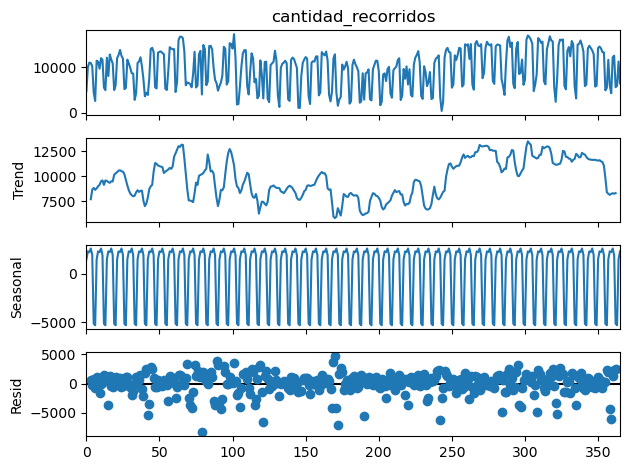

In [5]:
# Descomposición (usa 'additive' o 'multiplicative' según el comportamiento de la serie)
decomposition = seasonal_decompose(df_resumen['cantidad_recorridos'], model='additive', period=7)  # Por ejemplo: 7 si esperas estacionalidad semanal

# Plot
decomposition.plot()
plt.tight_layout()
plt.show()

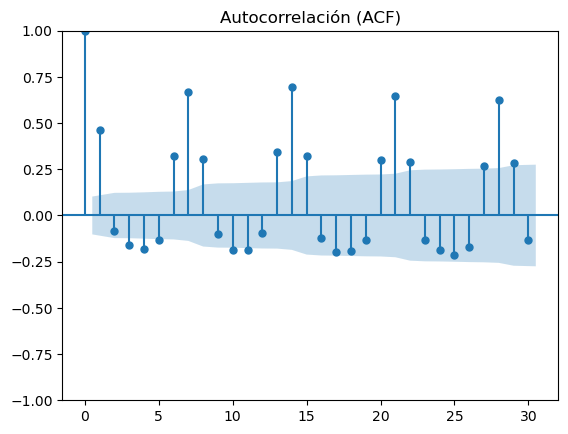

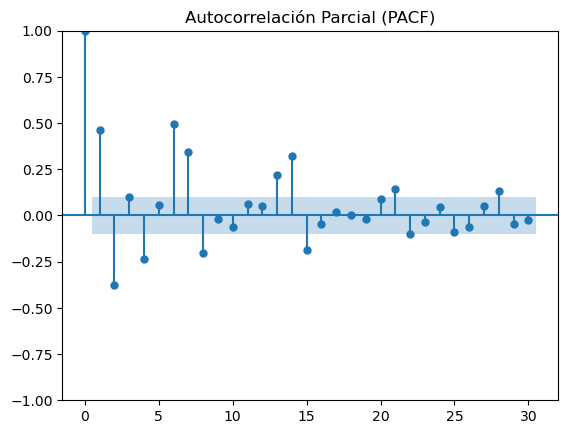

In [6]:
# ACF muestra correlaciones con lags anteriores
plot_acf(df_resumen['cantidad_recorridos'], lags=30)
plt.title('Autocorrelación (ACF)')
plt.show()

# PACF muestra correlaciones parciales (importante para AR terms)
plot_pacf(df_resumen['cantidad_recorridos'], lags=30)
plt.title('Autocorrelación Parcial (PACF)')
plt.show()

In [7]:
test_result = acorr_ljungbox(df_resumen['cantidad_recorridos'], lags=[7, 14, 21], return_df=True)
print(test_result)

       lb_stat      lb_pvalue
7   315.583544   2.834199e-64
14  615.224208  3.054744e-122
21  894.388725  8.329875e-176


c:\Users\usuario\miniconda3\envs\ADM\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ns will be used.
  self._init_dates(dates, freq)
c:\Users\usuario\miniconda3\envs\ADM\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ns will be used.
  self._init_dates(dates, freq)


MAE: 1977.52, RMSE: 3349.38


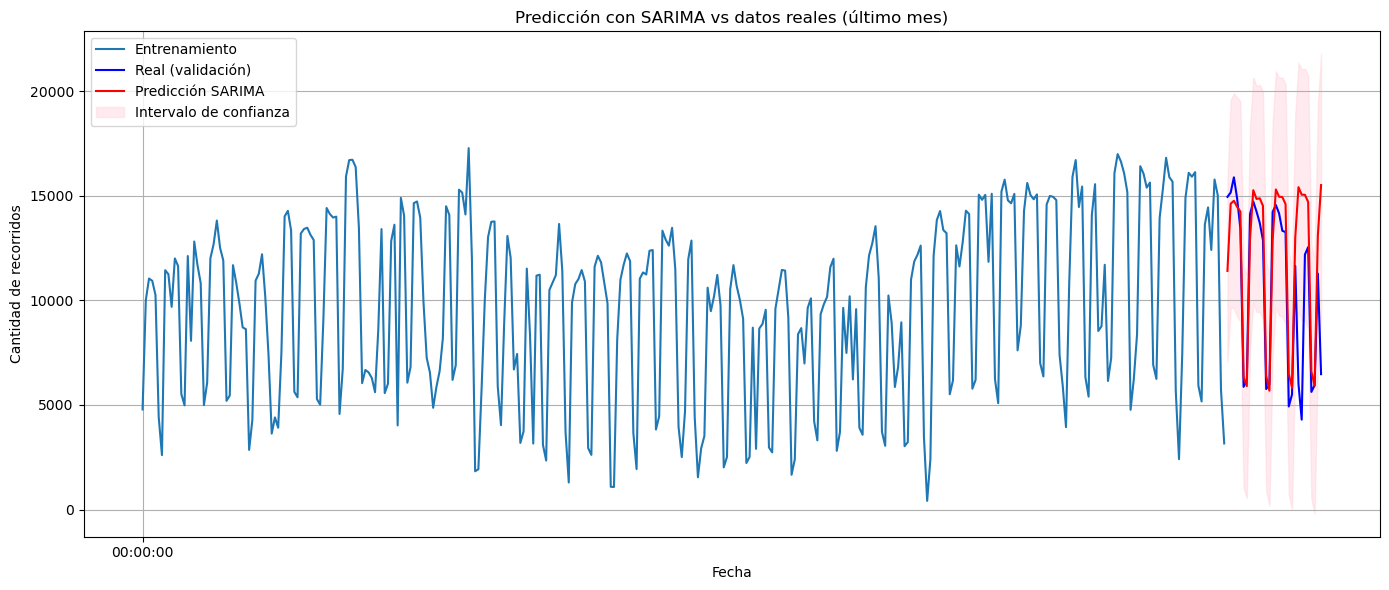

In [8]:
# Asegurar que el índice es datetime
df_resumen.index = pd.to_datetime(df_resumen.index)

# Separar el último mes (30 días) para validación
n_valid = 30
train = df_resumen.iloc[:-n_valid]
valid = df_resumen.iloc[-n_valid:]

# Entrenar modelo SARIMA con estacionalidad semanal
model = SARIMAX(train['cantidad_recorridos'],
                order=(1, 1, 1),
                seasonal_order=(1, 1, 1, 7),
                enforce_stationarity=False,
                enforce_invertibility=False)

result = model.fit(disp=False)

# Predecir sobre el período de validación
forecast = result.get_forecast(steps=n_valid)
forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

# Evaluar el modelo
mae = mean_absolute_error(valid['cantidad_recorridos'], forecast_mean)
rmse = np.sqrt(mean_squared_error(valid['cantidad_recorridos'], forecast_mean))
print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}")

# Graficar resultados
plt.figure(figsize=(14, 6))
plt.plot(train.index, train['cantidad_recorridos'], label='Entrenamiento')
plt.plot(valid.index, valid['cantidad_recorridos'], label='Real (validación)', color='blue')
plt.plot(valid.index, forecast_mean, label='Predicción SARIMA', color='red')
plt.fill_between(valid.index,
                 conf_int.iloc[:, 0],
                 conf_int.iloc[:, 1],
                 color='pink', alpha=0.3, label='Intervalo de confianza')
plt.legend()
plt.title('Predicción con SARIMA vs datos reales (último mes)')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de recorridos')
plt.grid(True)
plt.tight_layout()
plt.show()


MAE: 1570.08, RMSE: 2097.85


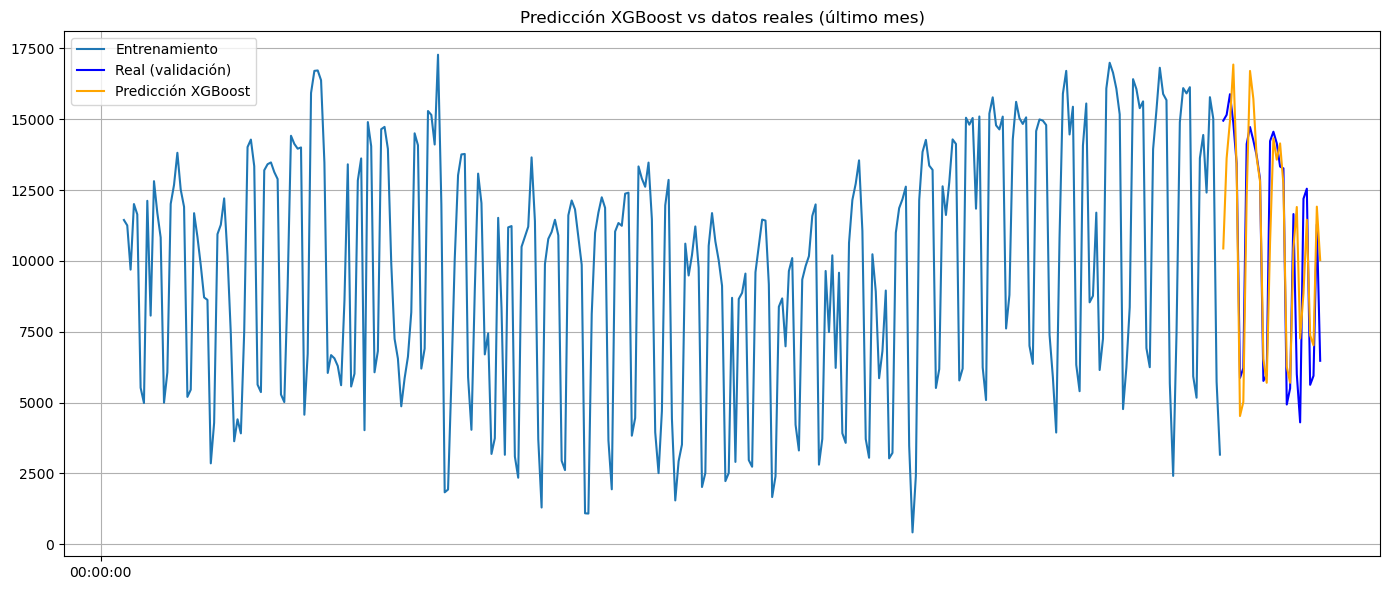

In [9]:
# Asumimos que df_resumen tiene un índice datetime y una columna 'cantidad_recorridos'
serie = df_resumen['cantidad_recorridos'].copy()

# Crear características: lags de los últimos 7 días
def create_lag_features(series, lags=7):
    df = pd.DataFrame({'target': series})
    for i in range(1, lags + 1):
        df[f'lag_{i}'] = series.shift(i)
    return df.dropna()

df_lags = create_lag_features(serie)

# Separar en train y valid (últimos 30 días)
n_valid = 30
train = df_lags.iloc[:-n_valid]
valid = df_lags.iloc[-n_valid:]

X_train = train.drop(columns='target')
y_train = train['target']
X_valid = valid.drop(columns='target')
y_valid = valid['target']

# Entrenar XGBoost
model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
model.fit(X_train, y_train)

# Predecir y evaluar
y_pred = model.predict(X_valid)

mae = mean_absolute_error(y_valid, y_pred)
rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}")

# Graficar
plt.figure(figsize=(14, 6))
plt.plot(y_train.index, y_train, label='Entrenamiento')
plt.plot(y_valid.index, y_valid, label='Real (validación)', color='blue')
plt.plot(y_valid.index, y_pred, label='Predicción XGBoost', color='orange')
plt.legend()
plt.title('Predicción XGBoost vs datos reales (último mes)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

def crear_ventanas_lags(df, feature_cols, target_col="cantidad_recorridos", window_size=7):
    df = df.copy()  # Evitamos modificar el DataFrame original
    columnas = []

    # Agregar las columnas de los features con lags t0 a t(window_size-1)
    for lag in range(window_size):
        for feature in feature_cols:
            col_name = f"{feature}_t{lag}"
            df[col_name] = df[feature].shift(-lag)
            columnas.append(col_name)
    
    # Agregar la columna objetivo (target) para t+window_size
    #target_name = f"{target_col}_t{window_size}"
    #df[target_name] = df[target_col].shift(-window_size)
    #columnas.append(target_name)

    # Eliminar las filas con valores NaN que se crean por el uso de shift
    df_lags = df[columnas].dropna().reset_index(drop=True)

    return df_lags
features = ["month", "day_of_month", "day_of_week", "is_weekend", "tavg", "prcp", "wspd", "cantidad_recorridos"]
model_df = crear_ventanas_lags(df_resumen, features)
model_df.head()

,month_t0,day_of_month_t0,day_of_week_t0,tavg_t0,prcp_t0,wspd_t0,cantidad_recorridos_t0,month_t1,day_of_month_t1,day_of_week_t1,...,prcp_t6,wspd_t6,cantidad_recorridos_t6,month_t7,day_of_month_t7,day_of_week_t7,tavg_t7,prcp_t7,wspd_t7,cantidad_recorridos_t7
0,1,1,1,25.2,2.2,9.5,4787,1.0,2.0,2.0,...,12.3,8.1,2605.0,1.0,8.0,1.0,24.8,55.9,4.5,11444.0
1,1,2,2,24.9,0.0,9.7,10017,1.0,3.0,3.0,...,55.9,4.5,11444.0,1.0,9.0,2.0,27.9,0.0,5.6,11252.0
2,1,3,3,24.2,9.9,11.6,11045,1.0,4.0,4.0,...,0.0,5.6,11252.0,1.0,10.0,3.0,27.6,1.0,7.2,9692.0
3,1,4,4,25.2,0.0,11.8,10936,1.0,5.0,5.0,...,1.0,7.2,9692.0,1.0,11.0,4.0,24.1,7.9,11.5,12007.0
4,1,5,5,21.2,3.0,11.4,10253,1.0,6.0,6.0,...,7.9,11.5,12007.0,1.0,12.0,5.0,21.8,0.0,9.8,11641.0


MAE: 1760.73, RMSE: 2847.35


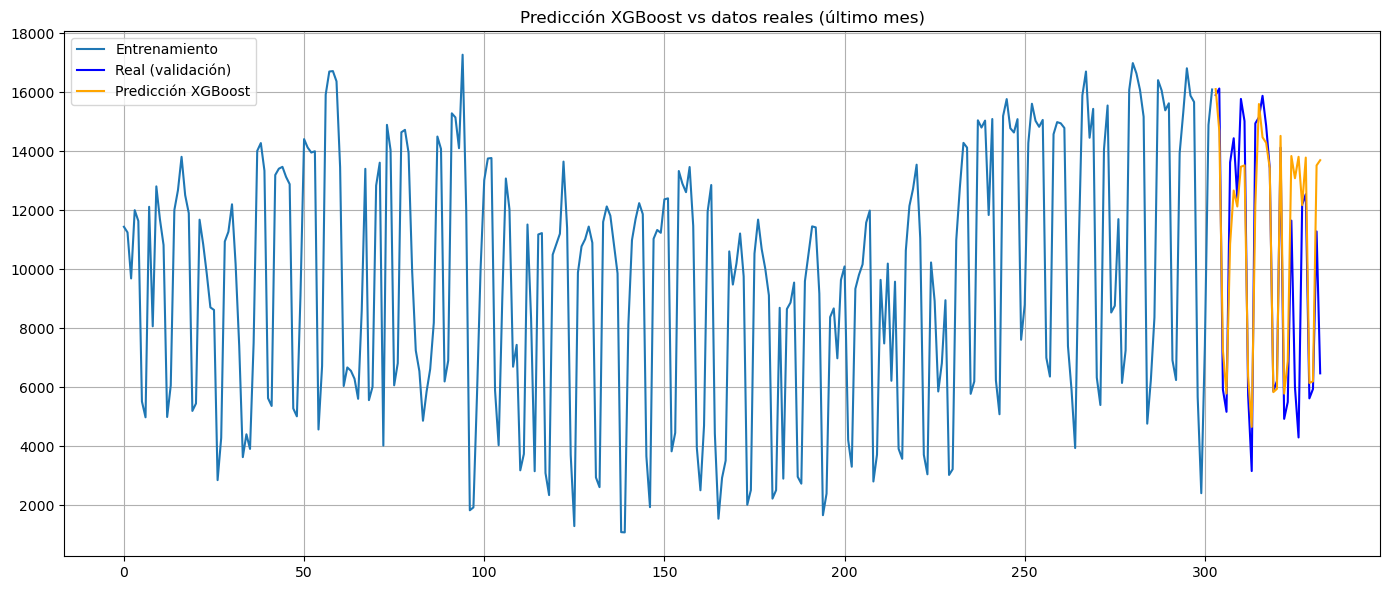

In [ ]:
# Separar en train y valid (últimos 30 días)
n_valid = 30
train = model_df.iloc[:-n_valid]
valid = model_df.iloc[-n_valid:]

X_train = train.drop(columns='cantidad_recorridos_t7')
y_train = train['cantidad_recorridos_t7']
X_valid = valid.drop(columns='cantidad_recorridos_t7')
y_valid = valid['cantidad_recorridos_t7']

In [ ]:

# Entrenar XGBoost
model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
model.fit(X_train, y_train)

# Predecir y evaluar
y_pred = model.predict(X_valid)

mae = mean_absolute_error(y_valid, y_pred)
rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}")

# Graficar
plt.figure(figsize=(14, 6))
plt.plot(y_train.index, y_train, label='Entrenamiento')
plt.plot(y_valid.index, y_valid, label='Real (validación)', color='blue')
plt.plot(y_valid.index, y_pred, label='Predicción XGBoost', color='orange')
plt.legend()
plt.title('Predicción XGBoost vs datos reales (último mes)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [20]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

# Assuming you have these periods for cyclical features
DAY_OF_MONTH_PERIOD = 31
DAY_OF_WEEK_PERIOD = 7
HOUR_PERIOD = 24


def sin_transformer(period, col_name):
    transformer = FunctionTransformer(lambda x: np.sin(x / period * 2 * np.pi))
    # Añadimos nombres de columnas manualmente
    transformer.get_feature_names_out = lambda input_features: [f"{col_name}_sin"]
    return transformer

def cos_transformer(period, col_name):
    transformer = FunctionTransformer(lambda x: np.cos(x / period * 2 * np.pi))
    transformer.get_feature_names_out = lambda input_features: [f"{col_name}_cos"]
    return transformer

# Create the column transformer
preprocessor = ColumnTransformer(
    transformers=[
        # One-hot encode month_of_year
        ('month_onehot', OneHotEncoder(), ['month']),
        
        # Transformaciones cíclicas (con nombres personalizados)
        ('day_of_month_sin', sin_transformer(31, "day_of_month"), ['day_of_month']),
        ('day_of_month_cos', cos_transformer(31, "day_of_month"), ['day_of_month']),
        
        ('day_of_week_sin', sin_transformer(7, "day_of_week"), ['day_of_week']),
        ('day_of_week_cos', cos_transformer(7, "day_of_week"), ['day_of_week']),
        
        # Standard scaling for tavg and wspd
        ('standard_scaler', StandardScaler(), ['tavg', 'wspd']),
        
        # MinMax scaling for prcp
        ('minmax_scaler', MinMaxScaler(), ['prcp'])
    ]
)


In [ ]:
# Separar en train y valid (últimos 30 días)
n_valid = 30
train = df_resumen[features].iloc[:-n_valid]
valid = df_resumen[features].iloc[-n_valid:]

X_train = train.drop(columns='cantidad_recorridos')
y_train = train['cantidad_recorridos']
X_valid = valid.drop(columns='cantidad_recorridos')
y_valid = valid['cantidad_recorridos']

# Create the full pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor)
])
pipeline.fit(X_train)
X_train_transform = pipeline.transform(X_train)
X_valid_transform = pipeline.transform(X_valid)

array([[ 1.        ,  0.        ,  0.        , ...,  1.18068477,
         0.29036873,  0.02315789],
       [ 1.        ,  0.        ,  0.        , ...,  1.12959745,
         0.35357825,  0.        ],
       [ 1.        ,  0.        ,  0.        , ...,  1.0103937 ,
         0.9540687 ,  0.10421053],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  0.82307352,
        -0.15209791,  0.09263158],
       [ 0.        ,  0.        ,  0.        , ...,  0.58466602,
         0.10074017,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.34625851,
         0.57481157,  0.29473684]], shape=(336, 19))